# Crawling

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [3]:
pip install requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [4]:
from bs4 import BeautifulSoup
import requests
url="https://arxiv.org/list/cs.GT/recent"
res=requests.get(url)
#res.encoding="utf-8"
print(res)
print(res.encoding)

<Response [200]>
utf-8


In [5]:
if res.status_code==200:
    print("Url is Connected")
elif res.status_code==404:
    print("Page not Found")
else:
    print("Url is Disconnected")

Url is Connected


In [6]:
soup = BeautifulSoup(res.text, "html.parser")
print(soup)

<!DOCTYPE html>

<html lang="en">
<head> <title>Computer Science and Game Theory  </title>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<link href="/static/browse/0.3.4/images/icons/apple-touch-icon.png" rel="apple-touch-icon" sizes="180x180"/>
<link href="/static/browse/0.3.4/images/icons/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/>
<link href="/static/browse/0.3.4/images/icons/favicon-16x16.png" rel="icon" sizes="16x16" type="image/png"/>
<link href="/static/browse/0.3.4/images/icons/site.webmanifest" rel="manifest"/>
<link color="#5bbad5" href="/static/browse/0.3.4/images/icons/safari-pinned-tab.svg" rel="mask-icon"/>
<meta content="#da532c" name="msapplication-TileColor"/>
<meta content="#ffffff" name="theme-color"/>
<link href="/static/browse/0.3.4/css/arXiv.css?v=20241206" media="screen" rel="stylesheet" type="text/css">
<link href="/static/browse/0.3.4/css/arXiv-print.css?v=20200611" media="print" rel="stylesheet" type="text/css">
<link

In [7]:
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Computer Science and Game Theory
  </title>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <link href="/static/browse/0.3.4/images/icons/apple-touch-icon.png" rel="apple-touch-icon" sizes="180x180"/>
  <link href="/static/browse/0.3.4/images/icons/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/>
  <link href="/static/browse/0.3.4/images/icons/favicon-16x16.png" rel="icon" sizes="16x16" type="image/png"/>
  <link href="/static/browse/0.3.4/images/icons/site.webmanifest" rel="manifest"/>
  <link color="#5bbad5" href="/static/browse/0.3.4/images/icons/safari-pinned-tab.svg" rel="mask-icon"/>
  <meta content="#da532c" name="msapplication-TileColor"/>
  <meta content="#ffffff" name="theme-color"/>
  <link href="/static/browse/0.3.4/css/arXiv.css?v=20241206" media="screen" rel="stylesheet" type="text/css">
   <link href="/static/browse/0.3.4/css/arXiv-print.css?v=20200611" media="print" rel="styles

In [8]:
soup.find_all('a')

[<a class="is-sr-only" href="#content">Skip to main content</a>,
 <a href="https://www.cornell.edu/"><img alt="Cornell University" src="/static/browse/0.3.4/images/icons/cu/cornell-reduced-white-SMALL.svg"/></a>,
 <a href="https://info.arxiv.org/about/ourmembers.html">member institutions</a>,
 <a class="btn-header-donate" href="https://info.arxiv.org/about/donate.html">Donate</a>,
 <a aria-hidden="true" href="/IgnoreMe" tabindex="-1"></a>,
 <a href="/"><img alt="arxiv logo" src="/static/browse/0.3.4/images/arxiv-logo-one-color-white.svg" style="height:40px;"/></a>,
 <a href="/list/cs.GT/recent">cs.GT</a>,
 <a href="https://info.arxiv.org/help">Help</a>,
 <a href="https://arxiv.org/search/advanced">Advanced Search</a>,
 <a href="https://arxiv.org/"><img alt="arXiv logo" src="/static/browse/0.3.4/images/arxiv-logomark-small-white.svg" style="height:60px;"/></a>,
 <a href="https://www.cornell.edu/">
 <picture>
 <source media="(min-width: 501px)" sizes="400w" srcset="/static/browse/0.3.4/i

In [9]:
url1 = "https://arxiv.org/list/cs.GT/recent?skip=0&show=100"
res1 = requests.get(url1)
soup = BeautifulSoup(res1.text, "html.parser")
article = soup.find("dl")

dts = article.find_all("dt")
dds = article.find_all("dd")

count = 0
for dt,dd in zip(dts[:10], dds[:10]):
    id = dt.find("a", title="Abstract")
    paper_id = id.text.strip()

    title_div = dd.find("div", class_="list-title mathjax")
    title = title_div.get_text(strip=True).strip()

    author_div = dd.find("div", class_="list-authors")
    author_links = author_div.find_all("a")
    authors = ", ".join([a.text.strip() for a in author_links])

    count+=1

    print("[",count,"]")
    print(paper_id)
    print(title)
    print(authors)
    print()

# for p in papers[:20]:
#     title_div = p.find("div", class_="list-title mathjax")
#     if title_div:
#         title = title_div.get_text(strip=True).replace("Title:", "").strip()
#         print("-", title)

[ 1 ]
arXiv:2602.15784
Title:Stability in Distance Preservation Games on Graphs
Argyrios Deligkas, Eduard Eiben, Tiger-Lily Goldsmith, Dušan Knop, Šimon Schierreich

[ 2 ]
arXiv:2602.15708
Title:Outer Diversity of Structured Domains
Piotr Faliszewski, Krzysztof Sornat, Stanisław Szufa, Tomasz Wąs

[ 3 ]
arXiv:2602.15566
Title:Simultaneous Ordinal Maximin Share and Envy-Based Guarantees
Hannaneh Akrami, Timo Reichert

[ 4 ]
arXiv:2602.15252
Title:Decision Making under Imperfect Recall: Algorithms and Benchmarks
Emanuel Tewolde, Brian Hu Zhang, Ioannis Anagnostides, Tuomas Sandholm, Vincent Conitzer

[ 5 ]
arXiv:2602.15233
Title:Computing Perfect Bayesian Equilibria, with Application to Empirical Game-Theoretic Analysis
Christine Konicki, Mithun Chakraborty, Michael P. Wellman

[ 6 ]
arXiv:2602.15225
Title:Equilibria in Large Position-Optimization Games
Rafael Frongillo, Melody Hsu, Mary Monroe, Anish Thilagar

[ 7 ]
arXiv:2602.15186
Title:Interbank Lending Games
Jinyun Tong, Bart de Kei

In [10]:
import pandas as pd
rows = []
count=0

for dt,dd in zip(dts[:20], dds[:20]):
    id = dt.find("a", title="Abstract")
    paper_id = id.text.strip()

    title_div = dd.find("div", class_="list-title mathjax")
    title = title_div.get_text(strip=True).replace("Title:", "").strip()

    author_div = dd.find("div", class_="list-authors")
    author_links = author_div.find_all("a")
    authors = ", ".join([a.text.strip() for a in author_links])

    count+=1
    rows.append([count, paper_id, title, authors])

df = pd.DataFrame(rows, columns=["index", "paper_id", "title", "authors"])

In [11]:
from IPython.display import display
display(df)

,index,paper_id,title,authors
0,1,arXiv:2602.15784,Stability in Distance Preservation Games on Gr...,"Argyrios Deligkas, Eduard Eiben, Tiger-Lily Go..."
1,2,arXiv:2602.15708,Outer Diversity of Structured Domains,"Piotr Faliszewski, Krzysztof Sornat, Stanisław..."
2,3,arXiv:2602.15566,Simultaneous Ordinal Maximin Share and Envy-Ba...,"Hannaneh Akrami, Timo Reichert"
3,4,arXiv:2602.15252,Decision Making under Imperfect Recall: Algori...,"Emanuel Tewolde, Brian Hu Zhang, Ioannis Anagn..."
4,5,arXiv:2602.15233,"Computing Perfect Bayesian Equilibria, with Ap...","Christine Konicki, Mithun Chakraborty, Michael..."
5,6,arXiv:2602.15225,Equilibria in Large Position-Optimization Games,"Rafael Frongillo, Melody Hsu, Mary Monroe, Ani..."
6,7,arXiv:2602.15186,Interbank Lending Games,"Jinyun Tong, Bart de Keijzer, Haoxiang Wang, C..."
7,8,arXiv:2602.15182,Autodeleveraging as Online Learning,"Tarun Chitra, Nagu Thogiti, Mauricio Jean Piee..."


# Clustering

## Lowercase Title

In [14]:
df1 = df.copy()
df1["title"] = df1["title"].str.lower()
df1

,index,paper_id,title,authors
0,1,arXiv:2602.15784,stability in distance preservation games on gr...,"Argyrios Deligkas, Eduard Eiben, Tiger-Lily Go..."
1,2,arXiv:2602.15708,outer diversity of structured domains,"Piotr Faliszewski, Krzysztof Sornat, Stanisław..."
2,3,arXiv:2602.15566,simultaneous ordinal maximin share and envy-ba...,"Hannaneh Akrami, Timo Reichert"
3,4,arXiv:2602.15252,decision making under imperfect recall: algori...,"Emanuel Tewolde, Brian Hu Zhang, Ioannis Anagn..."
4,5,arXiv:2602.15233,"computing perfect bayesian equilibria, with ap...","Christine Konicki, Mithun Chakraborty, Michael..."
5,6,arXiv:2602.15225,equilibria in large position-optimization games,"Rafael Frongillo, Melody Hsu, Mary Monroe, Ani..."
6,7,arXiv:2602.15186,interbank lending games,"Jinyun Tong, Bart de Keijzer, Haoxiang Wang, C..."
7,8,arXiv:2602.15182,autodeleveraging as online learning,"Tarun Chitra, Nagu Thogiti, Mauricio Jean Piee..."


## Stopword

In [16]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

df1["title"] = df1["title"].apply(remove_stopwords)
df1

,index,paper_id,title,authors
0,1,arXiv:2602.15784,stability distance preservation games graphs,"Argyrios Deligkas, Eduard Eiben, Tiger-Lily Go..."
1,2,arXiv:2602.15708,outer diversity structured domains,"Piotr Faliszewski, Krzysztof Sornat, Stanisław..."
2,3,arXiv:2602.15566,simultaneous ordinal maximin share envybased g...,"Hannaneh Akrami, Timo Reichert"
3,4,arXiv:2602.15252,decision making imperfect recall algorithms be...,"Emanuel Tewolde, Brian Hu Zhang, Ioannis Anagn..."
4,5,arXiv:2602.15233,computing perfect bayesian equilibria applicat...,"Christine Konicki, Mithun Chakraborty, Michael..."
5,6,arXiv:2602.15225,equilibria large positionoptimization games,"Rafael Frongillo, Melody Hsu, Mary Monroe, Ani..."
6,7,arXiv:2602.15186,interbank lending games,"Jinyun Tong, Bart de Keijzer, Haoxiang Wang, C..."
7,8,arXiv:2602.15182,autodeleveraging online learning,"Tarun Chitra, Nagu Thogiti, Mauricio Jean Piee..."


In [17]:
titles = df1["title"].tolist()
titles

['stability distance preservation games graphs',
 'outer diversity structured domains',
 'simultaneous ordinal maximin share envybased guarantees',
 'decision making imperfect recall algorithms benchmarks',
 'computing perfect bayesian equilibria application empirical gametheoretic analysis',
 'equilibria large positionoptimization games',
 'interbank lending games',
 'autodeleveraging online learning']

## bag of words

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(titles)

In [20]:
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns = bow_vec.get_feature_names_out()
)

bow_df

,algorithms,analysis,application,autodeleveraging,bayesian,benchmarks,computing,decision,distance,diversity,...,ordinal,outer,perfect,positionoptimization,preservation,recall,share,simultaneous,stability,structured
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
3,1,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,1,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## TF-IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer(
    ngram_range=(1,2)
)
tfidf_matrix = tfidf_vec.fit_transform(titles)

In [23]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vec.get_feature_names_out()
)
tfidf_df.head()

,algorithms,algorithms benchmarks,analysis,application,application empirical,autodeleveraging,autodeleveraging online,bayesian,bayesian equilibria,benchmarks,...,recall,recall algorithms,share,share envybased,simultaneous,simultaneous ordinal,stability,stability distance,structured,structured domains
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.342534,0.342534,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377964,0.377964
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.301511,0.301511,0.301511,0.301511,0.000000,0.000000,0.000000,0.000000
3,0.301511,0.301511,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.301511,...,0.301511,0.301511,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.260799,0.260799,0.260799,0.0,0.0,0.260799,0.260799,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Cosine Sim

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
cosine = cosine_similarity(tfidf_matrix)

In [26]:
cosine_df = pd.DataFrame(
    cosine, index = titles,
    columns = titles
)

cosine_df

,stability distance preservation games graphs,outer diversity structured domains,simultaneous ordinal maximin share envybased guarantees,decision making imperfect recall algorithms benchmarks,computing perfect bayesian equilibria application empirical gametheoretic analysis,equilibria large positionoptimization games,interbank lending games,autodeleveraging online learning
stability distance preservation games graphs,1.000000,0.0,0.0,0.0,0.000000,0.071801,0.084236,0.0
outer diversity structured domains,0.000000,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
simultaneous ordinal maximin share envybased guarantees,0.000000,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.0
decision making imperfect recall algorithms benchmarks,0.000000,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.0
computing perfect bayesian equilibria application empirical gametheoretic analysis,0.000000,0.0,0.0,0.0,1.000000,0.073416,0.000000,0.0
equilibria large positionoptimization games,0.071801,0.0,0.0,0.0,0.073416,1.000000,0.098562,0.0
interbank lending games,0.084236,0.0,0.0,0.0,0.000000,0.098562,1.000000,0.0
autodeleveraging online learning,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.0


In [27]:
cosine_df.iloc[5].sort_values(ascending=False)

equilibria large positionoptimization games                                           1.000000
interbank lending games                                                               0.098562
computing perfect bayesian equilibria application empirical gametheoretic analysis    0.073416
stability distance preservation games graphs                                          0.071801
outer diversity structured domains                                                    0.000000
simultaneous ordinal maximin share envybased guarantees                               0.000000
decision making imperfect recall algorithms benchmarks                                0.000000
autodeleveraging online learning                                                      0.000000
Name: equilibria large positionoptimization games, dtype: float64

# Kmeans

In [29]:
from sklearn.cluster import KMeans

In [30]:
k = 4
kmeans = KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20
)

kmeans.fit(tfidf_matrix)

KMeans(n_clusters=4, n_init=20, random_state=42)

In [31]:
labels = kmeans.labels_
cluster_df = pd.DataFrame({
    "title": titles,
    "cluster": labels
})

cluster_df

,title,cluster
0,stability distance preservation games graphs,0
1,outer diversity structured domains,2
2,simultaneous ordinal maximin share envybased g...,1
3,decision making imperfect recall algorithms be...,1
4,computing perfect bayesian equilibria applicat...,1
5,equilibria large positionoptimization games,0
6,interbank lending games,0
7,autodeleveraging online learning,3


## top term

In [33]:
import numpy as np
terms = tfidf_vec.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    center = kmeans.cluster_centers_[i]
    top = center.argsort()[-10:][::-1]

    for idx in top:
        print(terms[idx])


Cluster 0:
games
interbank
lending
interbank lending
lending games
positionoptimization games
equilibria large
large positionoptimization
large
positionoptimization

Cluster 1:
imperfect recall
ordinal maximin
algorithms benchmarks
benchmarks
decision
decision making
envybased
envybased guarantees
guarantees
imperfect

Cluster 2:
structured domains
outer diversity
structured
domains
diversity structured
diversity
outer
autodeleveraging online
bayesian
algorithms benchmarks

Cluster 3:
learning
autodeleveraging
online
autodeleveraging online
online learning
games
games graphs
gametheoretic
equilibria large
domains


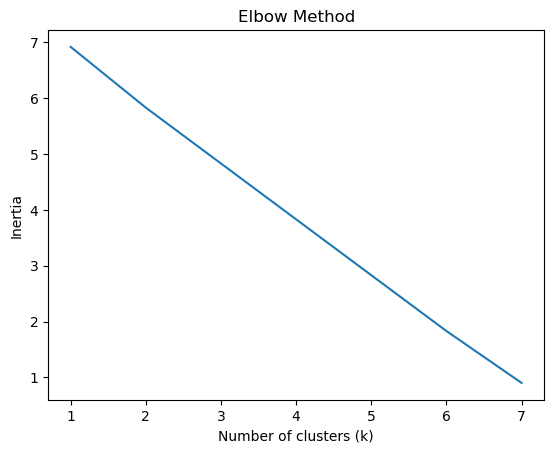

In [34]:
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

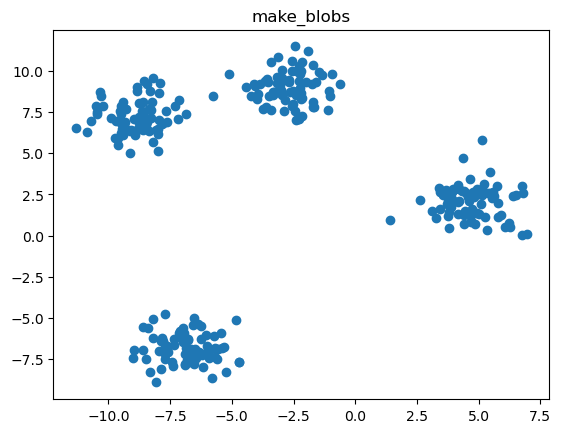

In [35]:
from sklearn.datasets import make_blobs

X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("make_blobs")
plt.show()

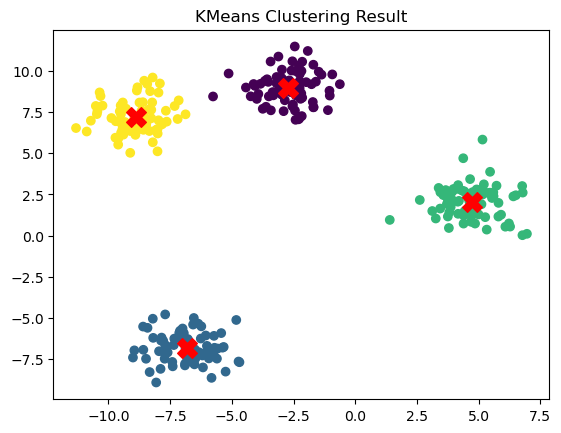

In [67]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, color='red')
plt.title("KMeans Clustering Result")
plt.show()